# Step 4 — Project the 11 ST clusters onto METABRIC

Performs the Seurat anchor-based transfer of TCGA's 11 ST-cluster labels onto each
METABRIC SpaGCN domain, aggregates per-domain predictions to per-patient cluster
proportions, and renders the z-score heatmap from the paper (Figure S7A).

The transfer pipeline (FindTransferAnchors → TransferData → per-patient
aggregation) lives in [`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R).
The notebook only invokes it; tuned parameter values are inside the helper.

## Setup

In [1]:
import sys, subprocess
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from clustering_helpers import (
    SPATIOTYPE_PALETTE, HEATMAP_ROW_ORDER,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

# Inputs (large Seurat objects; held on Biowulf and not committed)
REFERENCE_QS = "/vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs"
QUERY_QS     = "/vf/users/Ruppin_ST/Cell_revisions/spatial_clusters/METABRIC_seurat.qs"

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## What are `target` and `query`?

Both are Seurat objects produced upstream by the SpaGCN → per-domain pipeline. Each
"cell" is one SpaGCN domain (a spatially-coherent group of pseudo-spots on one slide).

- **`target` — TCGA reference.** 7,766 domains across 858 TCGA-BRCA slides. Its
  `mapped_clusters` metadata column has each domain's assigned ST cluster
  (`Cluster_1`…`Cluster_11`), produced by the cross-patient clustering in
  [notebook 02](02_seurat_cross_patient_TCGA.ipynb).
- **`query` — METABRIC.** 1,099 domains across 158 METABRIC slides. No cluster
  labels yet — the transfer step assigns them by finding nearest reference
  anchors in PCA space and propagating the label.

The cell below runs [`../lib/inspect_seurat.R`](../lib/inspect_seurat.R) to print
dimensions, metadata columns, the first four rows of `@meta.data`, and a label
distribution. Requires R + Seurat + qs and the `.qs` files.

In [2]:
def inspect_qs(qs_path, label):
    res = subprocess.run(
        ["bash", "-c",
         f"source /etc/profile.d/modules.sh 2>/dev/null; "
         f"module load R/4.3.2 2>/dev/null; "
         f"Rscript ../lib/inspect_seurat.R {qs_path} '{label}'"],
        capture_output=True, text=True,
    )
    # Strip Biowulf lscratch banner if present
    print("\n".join(l for l in res.stdout.splitlines()
                      if "lscratch" not in l))

# inspect_qs(REFERENCE_QS, "TCGA reference (target)")  # uncomment to run
# inspect_qs(QUERY_QS, "METABRIC query")               # uncomment to run

## Stage 1 — Project labels (Seurat anchor transfer + aggregation)

A single Python call invokes
[`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R).
That script defines two functions —

- `transfer_cluster_labels(reference, query)` runs `FindTransferAnchors` then
  `TransferData` and returns one predicted ST cluster per query domain.
- `aggregate_to_patient_proportions(per_domain)` collapses the per-domain table
  to a per-patient × per-cluster proportion matrix.

— and orchestrates them. The tuned anchor / scoring / weighting parameters
(recovered from the paper's grid-search result file) are kept inside those
functions rather than exposed here.

The output CSV is shipped pre-computed as `../data/metabric_cluster_props.csv`,
so the rest of this notebook runs standalone.

In [3]:
OUT_CSV = "../data/metabric_cluster_props.csv"

# Uncomment to re-run the projection (needs R + Seurat + the .qs files):
# subprocess.run(["bash", "-c",
#     f"source /etc/profile.d/modules.sh; module load R/4.3.2; "
#     f"Rscript ../lib/transfer_TCGA_to_external.R {REFERENCE_QS} {QUERY_QS} {OUT_CSV}"],
#     check=True)

per_patient = pd.read_csv(OUT_CSV, index_col=0)
per_patient.head()

,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8,Cluster_9,Cluster_10,Cluster_11
slide_name,,,,,,,,,,,
MB-0008,0,0.0,0,0.0,0,0.177880,0.128111,0,0.000000,0.694009,0
MB-0050,0,0.0,0,0.0,0,0.319728,0.000000,0,0.000000,0.680272,0
MB-0060,0,0.0,0,0.0,0,0.000000,0.358285,0,0.239826,0.401890,0
MB-0102,0,0.0,0,0.0,0,0.209350,0.162602,0,0.000000,0.628049,0
MB-0106,0,0.0,0,0.0,0,0.273782,0.000000,0,0.000000,0.726218,0


## Stage 2 — Heatmap of cluster proportions (z-score, paper style)

Per the paper (`scr_plots_v2/survival_figure/main_clustering_R.ipynb`), each row
(cluster) is z-scored across patients before plotting. Columns are grouped by
the projected SpatioType; rows are in the paper's frozen order. JAMA palette for
the SpatioType annotation bar.

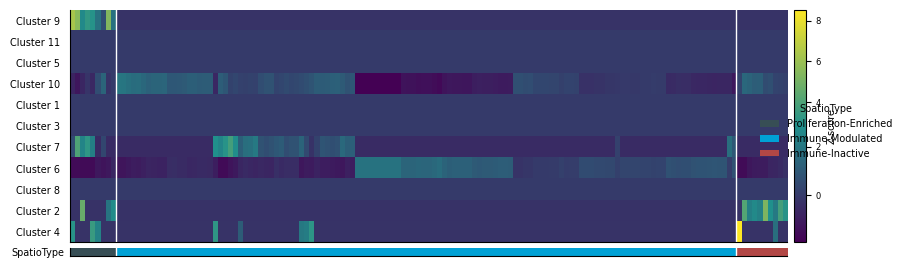

In [4]:
sp = pd.read_csv("../data/metabric_spatiotypes.csv", index_col=0)
df_h = per_patient.join(sp[["SpatioType"]], how="inner")

# Rename Cluster_<n> → "Cluster <n>" to match HEATMAP_ROW_ORDER
df_h = df_h.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})
df_h["SpatioType"] = df_h["SpatioType"].replace({"Proliferative": "Proliferation-Enriched"})

main_st = ["Proliferation-Enriched", "Immune-Modulated", "Immune-Inactive"]

# Column order: by SpatioType block, then Ward within block
from scipy.cluster.hierarchy import linkage, leaves_list
ordered = []
for st in main_st:
    block = df_h.index[df_h["SpatioType"] == st]
    if len(block) > 1:
        sub_mat = df_h.loc[block, HEATMAP_ROW_ORDER].values
        block = block[leaves_list(linkage(sub_mat, method="ward"))]
    ordered.extend(block)

raw = df_h.loc[ordered, HEATMAP_ROW_ORDER].T.values          # 11 × N (rows = clusters)
col_st = df_h.loc[ordered, "SpatioType"].values

# Row-wise z-score (per cluster, across patients)
mu  = raw.mean(axis=1, keepdims=True)
sig = raw.std(axis=1, keepdims=True)
sig[sig == 0] = 1
heat = (raw - mu) / sig

# Paper colour scale: 3-stop viridis ramp with midpoint = 2.85
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
v_lo  = float(heat.min())
v_mid = 2.85
v_hi  = float(heat.max())
cmap  = LinearSegmentedColormap.from_list(
    "viridis3", plt.get_cmap("viridis")(np.linspace(0, 1, 3)), N=256
)
norm  = TwoSlopeNorm(vmin=v_lo, vcenter=min(v_mid, v_hi - 1e-6), vmax=v_hi)

# Block boundaries
boundaries = []
prev = col_st[0]
for i, s in enumerate(col_st):
    if s != prev:
        boundaries.append(i); prev = s

fig = plt.figure(figsize=(9.5, 3.2))
gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[60, 1], height_ratios=[30, 1],
                       hspace=0.05, wspace=0.02)

ax_h = fig.add_subplot(gs[0, 0])
im = ax_h.imshow(heat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
for b in boundaries:
    ax_h.axvline(b - 0.5, color="white", linewidth=1.0)
ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
ax_h.set_xticks([]); ax_h.tick_params(left=False)

ax_cb = fig.add_subplot(gs[0, 1])
plt.colorbar(im, cax=ax_cb).set_label("Z-score", fontsize=7)
ax_cb.tick_params(labelsize=6)

ax_a = fig.add_subplot(gs[1, 0], sharex=ax_h)
rgb = np.array([list(mcolors.to_rgb(SPATIOTYPE_PALETTE[s])) for s in col_st])[None, :, :]
ax_a.imshow(rgb, aspect="auto", interpolation="nearest")
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_ylabel("SpatioType", rotation=0, ha="right", va="center", fontsize=7)
for b in boundaries:
    ax_a.axvline(b - 0.5, color="white", linewidth=1.0)

handles = [mpatches.Patch(facecolor=SPATIOTYPE_PALETTE[s], label=s) for s in main_st]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.0, 0.5),
           fontsize=7, frameon=False, title="SpatioType", title_fontsize=7)
plt.show()